# CV → Job Title Classifier — Proof of Learning

**מטרה:** להוכיח שהמיפוי טייטל אינו רק חיפוש דמיון (KNN / vector-DB) אלא **למידה אמיתית** —
מודל שלומד לסווג את התפקיד מתוך גוף הקו"ח (כישורים, אחריות, טכנולוגיות) גם כשהטייטל מוסתר.

מבנה המחברת:
- **Section B — Diagnostic (before):** baselines טריוויאליים + שחזור הקונפיג הנוכחי, על הלייבלים הגולמיים.
- **Section A — Improved models:** איחוד לייבלים (`label_map.py`), harness הערכה משותף, ואז
  **V1** (TF-IDF + LogReg) מול **V2** (Embeddings + linear), הכרעה ושמירה.

ההוכחה ללמידה נשענת על 3 רגליים: (1) פער עצום מול baseline, (2) יציבות ב-cross-validation,
(3) **learning curve** עולה, בתנאי מניעת-דליפה קפדני.

In [1]:
import json, os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from datetime import datetime

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, learning_curve
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from label_map import consolidate, FINAL_LABELS

warnings.filterwarnings("ignore")
pd.set_option("display.max_rows", 80)
RANDOM_STATE = 42
DATA_PATH = "./master_resumes.jsonl"
print("classes in label_map:", len(FINAL_LABELS))

classes in label_map: 38


## Data loading

לכל קו"ח בונים מסמך טקסט אחד מ-`summary + skills + experience`. שתי הגנות מפני **דליפת מידע**
(כדי שהמודל ילמד ולא "יעתיק" את הטייטל):
1. **`idx==0` guard:** מסירים את כותרת התפקיד הנוכחי (הלייבל) מבלוק הניסיון שלו.
2. **`scrub`:** מסירים את מחרוזת הטייטל הגולמי מכל הטקסט (בעיקר ה-summary) — ראו ניתוח הדליפה למטה.

In [2]:
def scrub_title(text, title):
    """Remove the raw current title verbatim (case-insensitive) — kills summary leakage."""
    if not title:
        return text
    return re.sub(re.escape(title), " ", text, flags=re.IGNORECASE)

def build_text(d, deleak=True):
    exp = d.get("experience", [])
    if not exp or not isinstance(exp, list):
        return None, None
    target = exp[0].get("title", "Unknown")
    if target in ["Unknown", "Not Provided", "", None]:
        return None, None
    blocks = []
    for idx, e in enumerate(exp):
        if not isinstance(e, dict):
            continue
        past = "" if idx == 0 else e.get("title", "")          # leakage guard #1
        resp = e.get("responsibilities", [])
        resp = " ".join(resp) if isinstance(resp, list) else ""
        te = e.get("technical_environment", {})
        techs = " ".join(te.get("technologies", [])) if isinstance(te, dict) else ""
        tools = " ".join(te.get("tools", [])) if isinstance(te, dict) else ""
        blocks.append(f"{past} {resp} {techs} {tools}")
    hist = " | ".join(blocks)
    summary = d.get("personal_info", {}).get("summary", "")
    ts = d.get("skills", {}).get("technical", {})
    skills = []
    for cat in ["programming_languages", "frameworks", "databases", "cloud"]:
        skills += [i.get("name", "") for i in ts.get(cat, []) if isinstance(i, dict)]
    text = f"SUMMARY_SEC {summary} SKILLS_SEC {' '.join(skills)} EXPERIENCE_SEC {hist}".strip()
    if deleak:
        text = scrub_title(text, target)                        # leakage guard #2
    return text, target.title().strip()

def load(path, deleak=True):
    rows = []
    for line in open(path, encoding="utf-8"):
        if not line.strip():
            continue
        try:
            text, label = build_text(json.loads(line), deleak=deleak)
            if text and label:
                rows.append({"raw_text": text, "raw_label": label})
        except Exception:
            continue
    return pd.DataFrame(rows)

df       = load(DATA_PATH, deleak=True)    # de-leaked — used for the honest models (Section A)
df_leaky = load(DATA_PATH, deleak=False)   # as-shipped text — used only to expose leakage (Section B)
print("records:", len(df))

records: 4817


### כמה דליפה יש בפועל?

בודקים כמה מה-summaries מכילים את שם התפקיד מילה-במילה. זו הסיבה שקונפיג נאיבי מגיע לדיוק
"מנופח" — הוא פשוט קורא את הטייטל מהטקסט.

In [3]:
tot = leak_full = leak_tok = 0
for line in open(DATA_PATH, encoding="utf-8"):
    if not line.strip():
        continue
    d = json.loads(line); exp = d.get("experience", [])
    if not exp:
        continue
    raw = exp[0].get("title", "")
    if not raw or raw in ["Unknown", "Not Provided"]:
        continue
    tot += 1
    summ = (d.get("personal_info", {}).get("summary", "") or "").lower()
    if raw.lower() in summ:
        leak_full += 1
    if any(t in summ for t in [w for w in re.split(r"[^a-z0-9+]+", raw.lower()) if len(w) > 2]):
        leak_tok += 1
print(f"records with FULL title verbatim in summary: {leak_full}/{tot}  ({leak_full/tot*100:.0f}%)")
print(f"records with a title token in summary:       {leak_tok}/{tot}  ({leak_tok/tot*100:.0f}%)")

records with FULL title verbatim in summary: 3720/4817  (77%)
records with a title token in summary:       3945/4817  (82%)


## Section B — Diagnostic baselines (before)

מדדים על מרחב הלייבלים **הגולמי** (61 מחלקות, כולל סינונימים מפוצלים וזנב ארוך של מחלקות נדירות),
כדי לקבל נקודת ייחוס לפני השיפור. שלושה מדדים: `accuracy`, `macro-F1` (מתייחס לכל מחלקה שווה),
`weighted-F1`.

In [4]:
def metrics_row(name, yt, yp):
    return {
        "model": name,
        "accuracy":    round(accuracy_score(yt, yp), 3),
        "macro_F1":    round(f1_score(yt, yp, average="macro", zero_division=0), 3),
        "weighted_F1": round(f1_score(yt, yp, average="weighted", zero_division=0), 3),
    }

# raw-label split (drop classes with <2 so stratify works)
vc = df_leaky["raw_label"].value_counts()
raw = df_leaky[df_leaky["raw_label"].isin(vc[vc >= 2].index)]
Xb, yb = raw["raw_text"], raw["raw_label"]
Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(Xb, yb, test_size=0.2, random_state=RANDOM_STATE, stratify=yb)
print(f"raw label space: {yb.nunique()} classes, {len(raw)} records")

CUR_STOPS = list(TfidfVectorizer(stop_words="english").get_stop_words()) + ["unknown", "provided", "role", "responsibilities"]

results_B = []
for strat in ["most_frequent", "stratified"]:
    dm = DummyClassifier(strategy=strat, random_state=RANDOM_STATE).fit(Xb_tr, yb_tr)
    results_B.append(metrics_row(f"Dummy ({strat})", yb_te, dm.predict(Xb_te)))

# reproduce the currently-shipped config: max_features=300, no label stop-words, leaky text
cur = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words=CUR_STOPS, max_features=300, ngram_range=(1, 2))),
    ("clf",   LogisticRegression(max_iter=300, class_weight="balanced", random_state=RANDOM_STATE)),
]).fit(Xb_tr, yb_tr)
results_B.append(metrics_row("current-config (leaky, 300f)", yb_te, cur.predict(Xb_te)))

pd.DataFrame(results_B)

raw label space: 61 classes, 4813 records


,model,accuracy,macro_F1,weighted_F1
0,Dummy (most_frequent),0.036,0.001,0.003
1,Dummy (stratified),0.024,0.019,0.024
2,"current-config (leaky, 300f)",0.911,0.922,0.905


**קריאת התוצאה:** ה-Dummy נותן רצפה (~0). ה-current-config מגיע ל-accuracy גבוה מאוד — אבל זה
**מנופח בגלל הדליפה** (77% מהטקסטים מכילים את הטייטל). זה לא מוכיח למידה. בקטע הבא נעבור למרחב
לייבלים נקי + מניעת דליפה, ונראה מה המודל *באמת* למד.

## Section A — Consolidated labels & honest models

### A1 — איחוד לייבלים
מ-65 לייבלים גולמיים ל-~38 מחלקות נקיות דרך `label_map.consolidate` (מיזוג סינונימים אמיתיים,
שמות קנוניים היכן שקיים, זריקת רעש לא-IC). ~99% מהדאטה נשמר.

In [5]:
df["label"] = df["raw_label"].map(consolidate)
dfa = df.dropna(subset=["label"]).copy()
vc = dfa["label"].value_counts()
dfa = dfa[dfa["label"].isin(vc[vc >= 10].index)]           # drop any residual tiny class
X, y = dfa["raw_text"].reset_index(drop=True), dfa["label"].reset_index(drop=True)
print(f"consolidated: {len(dfa)} records ({len(dfa)/len(df)*100:.1f}% retained), {y.nunique()} classes")
y.value_counts()

consolidated: 4789 records (99.4% retained), 38 classes


label
DevOps Engineer              435
Frontend Developer           300
Software Engineer            244
Backend Developer            200
Solutions Architect          200
Java Developer               186
Data Scientist               109
Security Engineer            107
Machine Learning Engineer    106
QA Automation Engineer       101
Database Administrator       101
JavaScript Developer         100
Fullstack Engineer           100
Angular Developer            100
Vue Developer                100
AI Engineer                  100
Data Engineer                100
MLOps Engineer               100
Deep Learning Engineer       100
Computer Vision Engineer     100
NLP Engineer                 100
iOS Developer                100
Android Developer            100
Mobile Developer             100
React Native Developer       100
Flutter Developer            100
Systems Engineer             100
Kubernetes Engineer          100
Platform Engineer            100
Cyber Security               100
Secu

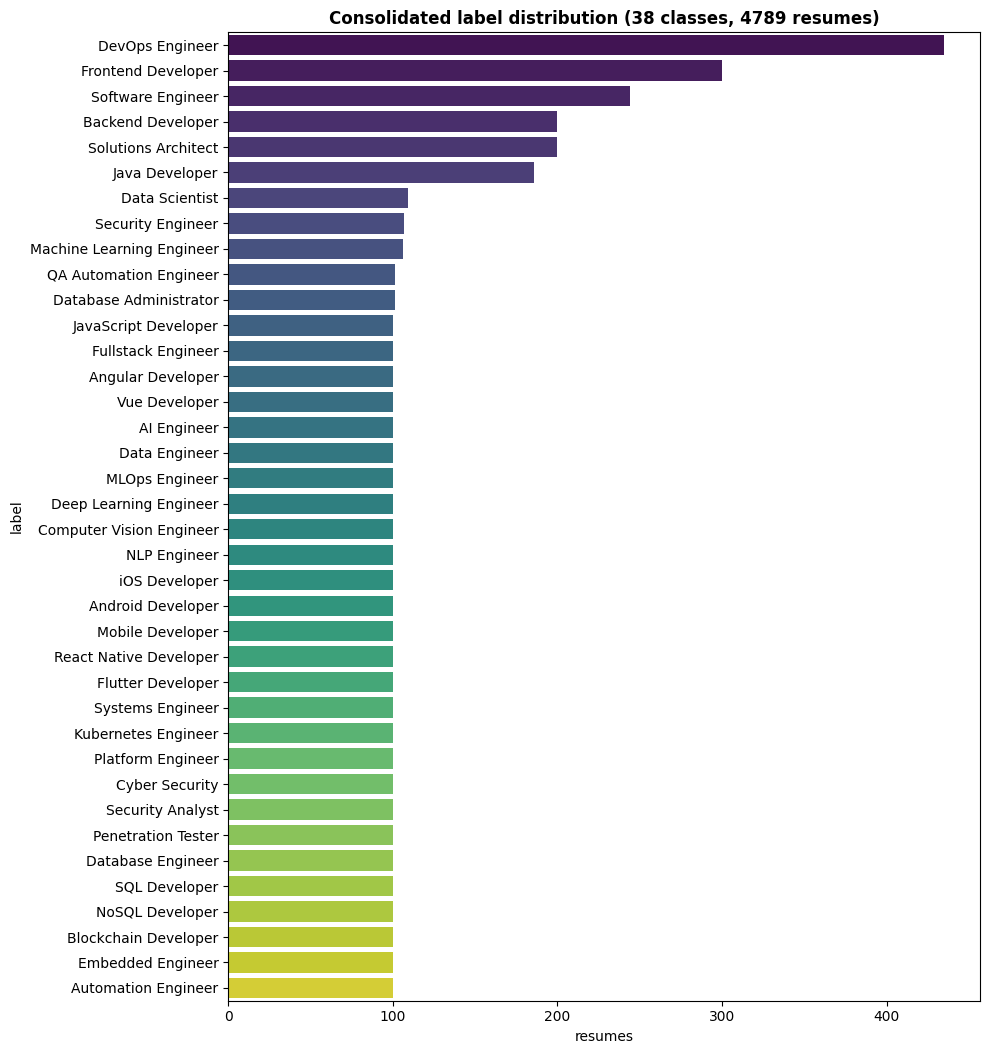

In [6]:
plt.figure(figsize=(10, len(y.unique()) * 0.28))
order = y.value_counts()
sns.barplot(x=order.values, y=order.index, hue=order.index, palette="viridis", legend=False)
plt.title(f"Consolidated label distribution ({y.nunique()} classes, {len(y)} resumes)", fontweight="bold")
plt.xlabel("resumes"); plt.tight_layout(); plt.show()

### A2 — Shared evaluation harness

פונקציה אחת שמריצה את שני המודלים באותו split ואותם מדדים כדי שההשוואה תהיה הוגנת:
`accuracy / macro-F1 / weighted-F1`, `classification_report`, confusion matrix, **5-fold CV** (יציבות),
ו-**learning curve** (ההוכחה הויזואלית ללמידה). ה-split מחושב פעם אחת על האינדקסים כדי ש-V1 (טקסט)
ו-V2 (embeddings) יראו בדיוק את אותן דוגמאות.

In [7]:
# one split shared by all models (indices → identical train/test rows for text and embeddings)
idx = np.arange(len(y))
idx_tr, idx_te = train_test_split(idx, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def evaluate(name, estimator, Xrep, y, show_report=True, learning=True):
    """Xrep: representation aligned to y (text Series for V1, embedding matrix for V2)."""
    Xtr = Xrep[idx_tr] if isinstance(Xrep, np.ndarray) else Xrep.iloc[idx_tr]
    Xte = Xrep[idx_te] if isinstance(Xrep, np.ndarray) else Xrep.iloc[idx_te]
    ytr, yte = y.iloc[idx_tr], y.iloc[idx_te]

    est = estimator.fit(Xtr, ytr)
    yp = est.predict(Xte)
    row = metrics_row(name, yte, yp)

    cv = cross_val_score(estimator, Xrep, y, cv=CV, scoring="f1_macro")
    row["cv_macroF1_mean"] = round(cv.mean(), 3)
    row["cv_macroF1_std"]  = round(cv.std(), 3)
    print(f"=== {name} ===")
    print(f"test: acc={row['accuracy']}  macroF1={row['macro_F1']}  wF1={row['weighted_F1']}")
    print(f"5-fold CV macroF1 = {cv.mean():.3f} +/- {cv.std():.3f}")

    if show_report:
        print(classification_report(yte, yp, zero_division=0))
        labels = sorted(y.unique())
        cm = confusion_matrix(yte, yp, labels=labels)
        plt.figure(figsize=(13, 11))
        sns.heatmap(cm, cmap="Blues", xticklabels=labels, yticklabels=labels, square=True, cbar=False)
        plt.title(f"Confusion matrix — {name}"); plt.xlabel("predicted"); plt.ylabel("actual")
        plt.xticks(rotation=90, fontsize=7); plt.yticks(rotation=0, fontsize=7)
        plt.tight_layout(); plt.show()

    if learning:
        sizes, tr_sc, cv_sc = learning_curve(estimator, Xrep, y, cv=CV, scoring="f1_macro",
                                             train_sizes=np.linspace(0.1, 1.0, 6), n_jobs=-1)
        plt.figure(figsize=(7, 4))
        plt.plot(sizes, tr_sc.mean(1), "o-", label="train")
        plt.plot(sizes, cv_sc.mean(1), "o-", label="cross-val")
        plt.fill_between(sizes, cv_sc.mean(1)-cv_sc.std(1), cv_sc.mean(1)+cv_sc.std(1), alpha=0.15)
        plt.title(f"Learning curve — {name}"); plt.xlabel("training examples"); plt.ylabel("macro-F1")
        plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
    return row

results_A = []

### A3 — V1: TF-IDF + Logistic Regression (fixed)

תיקונים מול הקוד הישן: `max_features=2000` (במקום 300), `min_df=2`.

**הערה חשובה על מניעת דליפה:** מנטרלים דליפה *רק* דרך `scrub` (הסרת הטייטל הגולמי מהטקסט).
**לא** מוסיפים את מילות הלייבלים ל-stop-words — כי מונחים כמו `react`, `angular`, `vue`, `sql`
הם גם *כישורים לגיטימיים* וגם שמות תפקידים, והסרתם מהאוצר-מילים הורסת את האות המבחין של
התפקידים הממוקדי-פריימוורק (במדידה: הסרתם הורידה את Angular/Vue/Frontend ל-F1~0.2). `scrub`
מסיר את מחרוזת הטייטל עצמה — זה מספיק כדי למנוע "העתקה" בלי לפגוע בכישורים.

=== V1 TF-IDF + LogReg ===
test: acc=0.911  macroF1=0.931  wF1=0.917
5-fold CV macroF1 = 0.932 +/- 0.004
                           precision    recall  f1-score   support

              AI Engineer       1.00      1.00      1.00        20
        Android Developer       1.00      1.00      1.00        20
        Angular Developer       0.47      0.85      0.61        20
      Automation Engineer       1.00      1.00      1.00        20
        Backend Developer       0.90      0.70      0.79        40
     Blockchain Developer       1.00      1.00      1.00        20
 Computer Vision Engineer       1.00      1.00      1.00        20
           Cyber Security       1.00      1.00      1.00        20
            Data Engineer       1.00      1.00      1.00        20
           Data Scientist       1.00      0.91      0.95        22
   Database Administrator       1.00      1.00      1.00        20
        Database Engineer       0.74      1.00      0.85        20
   Deep Learning Engine

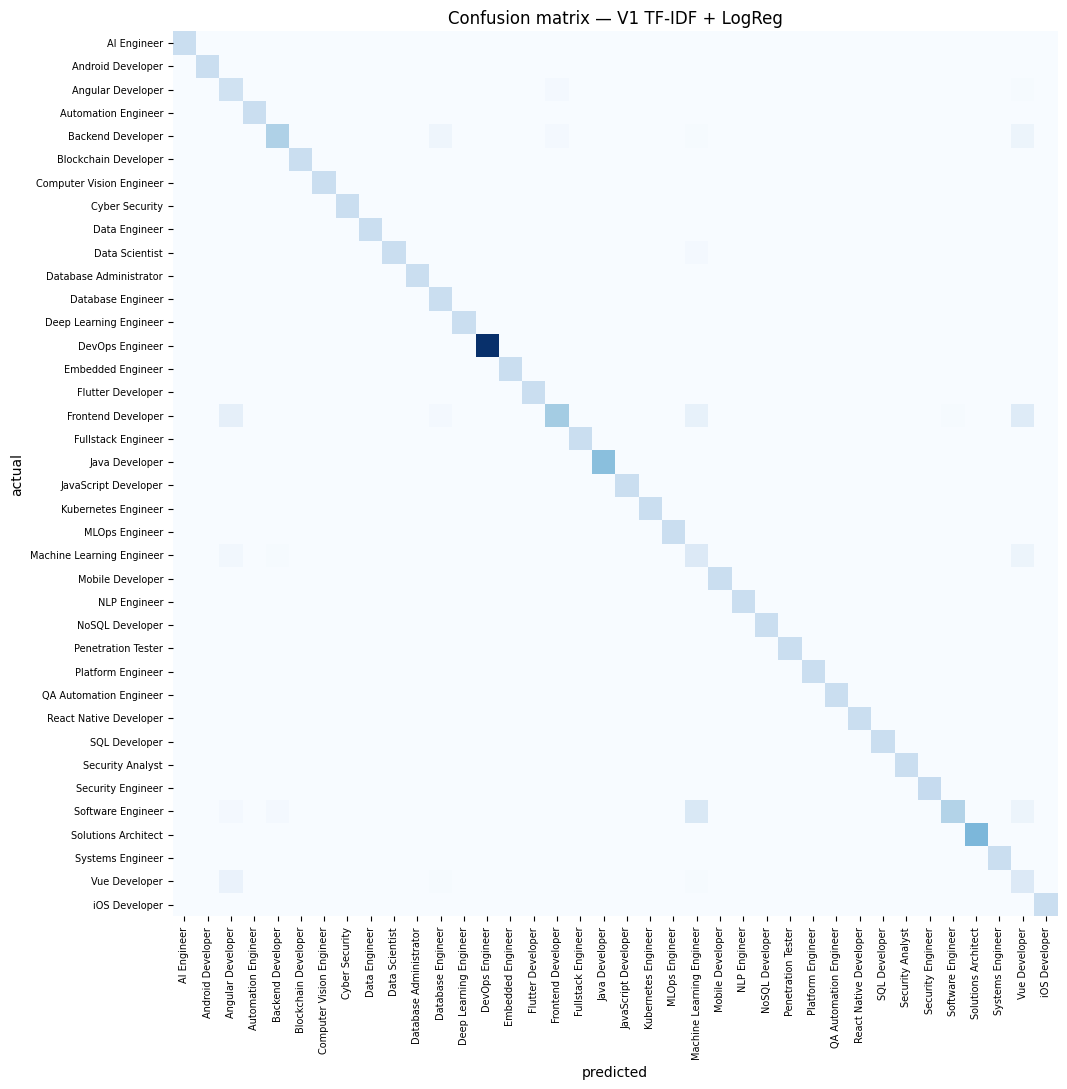

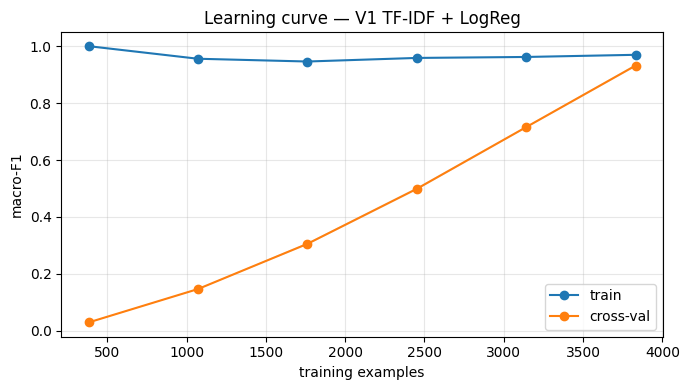

In [8]:
V1_STOPS = list(TfidfVectorizer(stop_words="english").get_stop_words()) + \
           ["unknown", "provided", "role", "responsibilities"]

v1 = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words=V1_STOPS, max_features=2000, ngram_range=(1, 2), min_df=2)),
    ("clf",   LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
])
results_A.append(evaluate("V1 TF-IDF + LogReg", v1, X, y))

#### Leakage ablation — האם המודל "לומד" או "מעתיק"?

מריצים בדיוק את אותו V1 על אותן 38 מחלקות, פעם על טקסט **de-leaked** (scrub) ופעם על הטקסט
**הגולמי** (הטייטל נשאר ב-summary). הפער מודד כמה מהביצועים היו "העתקה" ולא למידה.

In [9]:
df_leaky["label"] = df_leaky["raw_label"].map(consolidate)
dfl = df_leaky.dropna(subset=["label"])
dfl = dfl[dfl["label"].isin(vc[vc >= 10].index)]
Xleak = dfl["raw_text"].reset_index(drop=True)

v1_probe = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words=V1_STOPS, max_features=2000, ngram_range=(1, 2), min_df=2)),
    ("clf",   LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
])
cv_clean = cross_val_score(v1, X,     y,                 cv=CV, scoring="f1_macro")
cv_leaky = cross_val_score(v1_probe, Xleak, dfl["label"], cv=CV, scoring="f1_macro")
print(f"leaky text (title in summary): CV macroF1 = {cv_leaky.mean():.3f}")
print(f"de-leaked text (scrub):        CV macroF1 = {cv_clean.mean():.3f}")
print(f"=> leakage inflation removed:  {cv_leaky.mean() - cv_clean.mean():+.3f}")
print("The de-leaked score is the honest 'proof of learning' number.")

leaky text (title in summary): CV macroF1 = 0.981
de-leaked text (scrub):        CV macroF1 = 0.932
=> leakage inflation removed:  +0.049
The de-leaked score is the honest 'proof of learning' number.


### A4 — V2: Sentence-embeddings + linear classifier

מקודדים כל קו"ח ל-vector סמנטי (`all-MiniLM-L6-v2`) ומאמנים מעליו LogReg. ייצוג נלמד/סמנטי — לרוב
חזק יותר ל-38 מחלקות, ומחזק עוד את טיעון הלמידה. (הטקסט כבר de-leaked מ-A1.)

In [10]:
from sentence_transformers import SentenceTransformer
encoder = SentenceTransformer("all-MiniLM-L6-v2")
Xemb = encoder.encode(X.tolist(), batch_size=64, show_progress_bar=True, normalize_embeddings=True)
Xemb = np.asarray(Xemb)
print("embeddings:", Xemb.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3612.88it/s]

Batches:   0%|          | 0/75 [00:00<?, ?it/s]

Batches:   1%|▏         | 1/75 [00:02<03:20,  2.70s/it]

Batches:   3%|▎         | 2/75 [00:05<03:00,  2.47s/it]

...

Batches:  97%|█████████▋| 73/75 [02:26<00:03,  1.85s/it]

Batches:  99%|█████████▊| 74/75 [02:27<00:01,  1.78s/it]

Batches: 100%|██████████| 75/75 [02:29<00:00,  1.69s/it]

Batches: 100%|██████████| 75/75 [02:29<00:00,  1.99s/it]

embeddings: (4789, 384)


=== V2 Embeddings + LogReg ===
test: acc=0.844  macroF1=0.869  wF1=0.844
5-fold CV macroF1 = 0.861 +/- 0.005
                           precision    recall  f1-score   support

              AI Engineer       1.00      1.00      1.00        20
        Android Developer       1.00      1.00      1.00        20
        Angular Developer       0.50      0.60      0.55        20
      Automation Engineer       0.87      1.00      0.93        20
        Backend Developer       0.78      0.45      0.57        40
     Blockchain Developer       1.00      1.00      1.00        20
 Computer Vision Engineer       0.91      1.00      0.95        20
           Cyber Security       0.91      1.00      0.95        20
            Data Engineer       1.00      1.00      1.00        20
           Data Scientist       0.81      1.00      0.90        22
   Database Administrator       1.00      1.00      1.00        20
        Database Engineer       0.29      0.45      0.35        20
   Deep Learning En

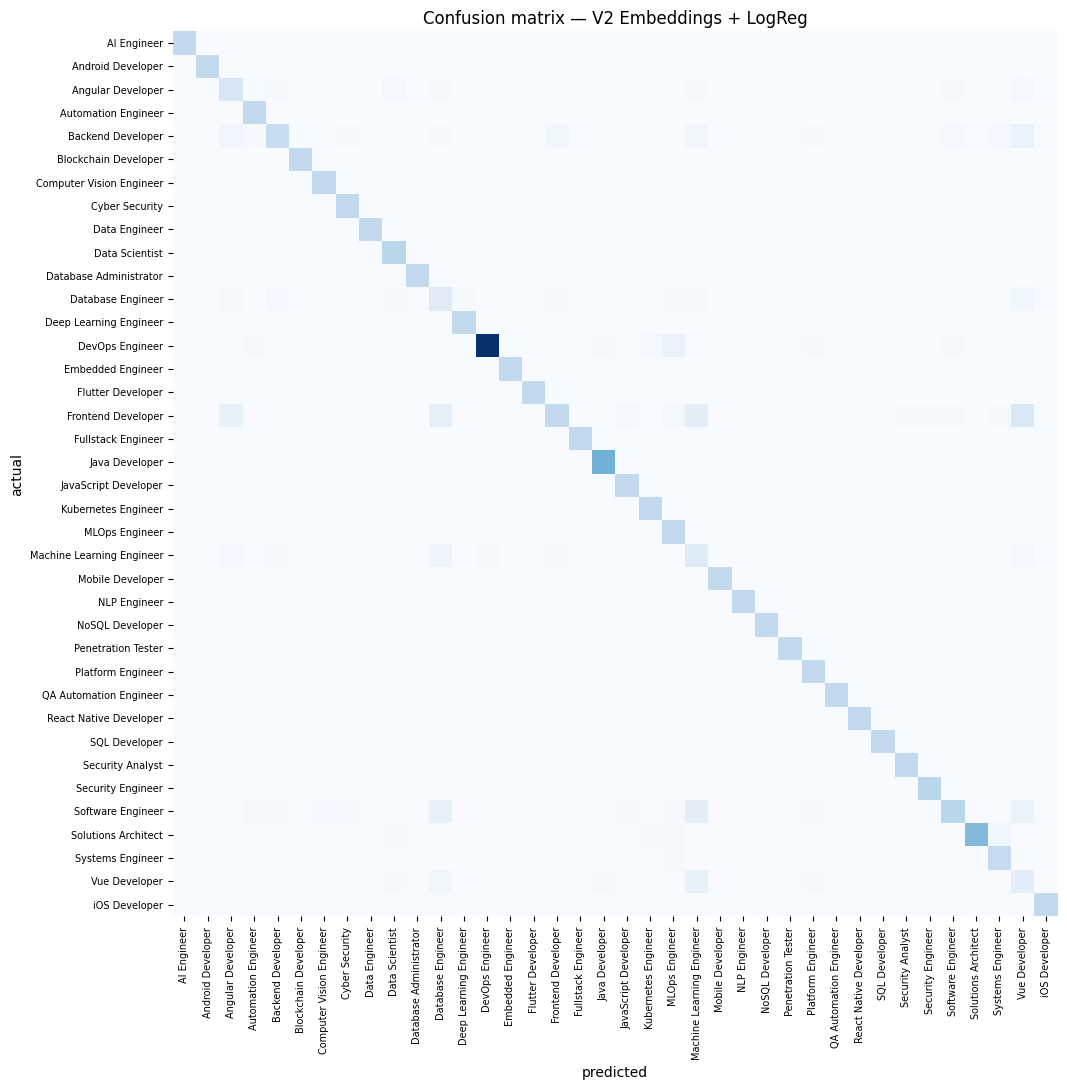

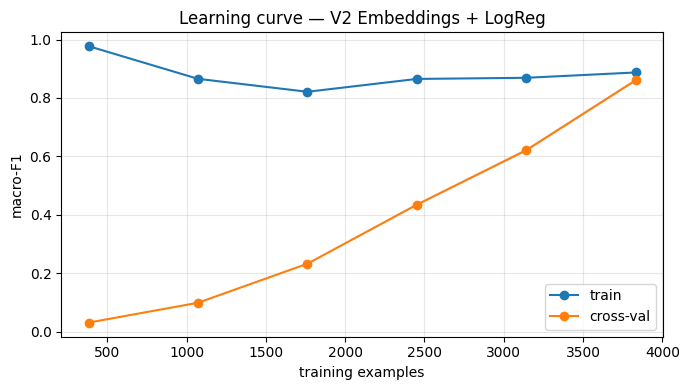

In [11]:
v2 = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)
results_A.append(evaluate("V2 Embeddings + LogReg", v2, Xemb, y))

### A5 — Comparison & final model

מרכזים את כל המדדים. הכרעה לפי `macro-F1` על ה-test, יציבות ה-CV, ומחלקות קטנות.

In [12]:
cmp = pd.DataFrame(results_A)[["model", "accuracy", "macro_F1", "weighted_F1", "cv_macroF1_mean", "cv_macroF1_std"]]
dummy_consol = DummyClassifier(strategy="most_frequent").fit(X.iloc[idx_tr], y.iloc[idx_tr])
dummy_row = metrics_row("Dummy (most_frequent)", y.iloc[idx_te], dummy_consol.predict(X.iloc[idx_te]))
cmp = pd.concat([pd.DataFrame([dummy_row]), cmp], ignore_index=True)
print("Baseline vs learned models (consolidated 38-class space):")
cmp

Baseline vs learned models (consolidated 38-class space):


,model,accuracy,macro_F1,weighted_F1,cv_macroF1_mean,cv_macroF1_std
0,Dummy (most_frequent),0.091,0.004,0.015,NaN,NaN
1,V1 TF-IDF + LogReg,0.911,0.931,0.917,0.932,0.004
2,V2 Embeddings + LogReg,0.844,0.869,0.844,0.861,0.005


In [13]:
# pick the winner by test macro-F1 (among the two learned models), retrain on ALL data, save
best = max(results_A, key=lambda r: r["macro_F1"])
best_name = best["model"]
print("winner:", best_name)

if best_name.startswith("V1"):
    final_model = v1.fit(X, y)                       # full pipeline; predict_proba on raw text
    artifact = final_model                            # server API unchanged
else:
    final_clf = v2.fit(Xemb, y)
    artifact = {"encoder_name": "all-MiniLM-L6-v2", "classifier": final_clf, "labels": sorted(y.unique())}

ts = datetime.now().strftime("%Y%m%d_%H%M%S")
joblib.dump(artifact, "./text_to_job_title_classifier.joblib")
joblib.dump(artifact, f"./text_to_job_title_classifier_{ts}.joblib")
print("saved: text_to_job_title_classifier.joblib  (+ versioned)")

winner: V1 TF-IDF + LogReg


saved: text_to_job_title_classifier.joblib  (+ versioned)


### Sanity check — the Frontend CV
בגרסה הישנה ה-top-1 היה React Native Developer ב-26.8% בלבד (ביטחון מפוצל). נריץ שוב על אותו CV.

In [14]:
cv_text1 = """
Natalie Foster — Senior Frontend Engineer with 6+ years building high-performance, accessible web
applications at scale. Expert in React, TypeScript, and web performance optimisation. Led frontend
architecture for platforms with 10M+ users. Built a component library of 60+ accessible React/TypeScript
components. Improved LCP by 65% and reduced JavaScript bundle size by 50% via code-splitting and lazy
loading. Next.js server-side rendering, Redux Toolkit, Zustand, React Query, Jest, React Testing Library,
Cypress, Webpack, Vite, Module Federation, GraphQL, WebSockets, WCAG 2.1 accessibility, Core Web Vitals.
"""

if best_name.startswith("V1"):
    proba = final_model.predict_proba([cv_text1])[0]
    classes = final_model.classes_
else:
    emb = encoder.encode([cv_text1], normalize_embeddings=True)
    proba = final_clf.predict_proba(emb)[0]
    classes = final_clf.classes_

top = pd.DataFrame({"job_title": classes, "confidence_%": (proba * 100).round(2)}) \
        .sort_values("confidence_%", ascending=False).head(5)
print("--- TOP 5 ---")
for _, r in top.iterrows():
    print(f"  {r['job_title']:28} {r['confidence_%']:.2f}%")

--- TOP 5 ---
  Frontend Developer           18.71%
  React Native Developer       10.09%
  Backend Developer            6.88%
  Software Engineer            6.25%
  Java Developer               6.14%
